## $ \chi_{df}^2 $ 분포
밀도, 확률, 구간, 임계치

In [1]:
# 카이제곱 분포 pdf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats   # 이렇게 하면 stats.norm(어쩌구)
from scipy.stats import norm, t, chi2, f  # 이렇게 하면 norm(어쩌구...


$ X \sim \chi_k^2  $, 이때 $ X $의 밀도 at $ x $.
 $$  f(x; k) = \frac{1}{2^{k/2} \Gamma(k/2)} x^{k/2 - 1} e^{-x/2}
 $$
$ k $: 자유도. $ \Gamma $: 감마함수(난이도 높은 함수, 스킵)

특정 지점 $ x $에서 카이제곱 밀도는 자유도에 달렸음.

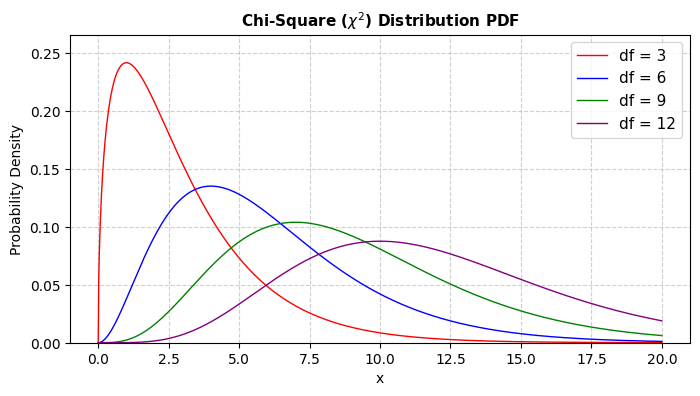

In [7]:
# 1. X축 범위 설정 (카이제곱 분포는 0 이상의 값만 가짐)
x = np.linspace(0, 20, 1000)

plt.figure(figsize=(8, 4))

# 2. 자유도(df)를 1, 2, 4, 8로 바꾸며 밀도함수(pdf) 그리기
degrees_of_freedom = [3, 6, 9, 12]
colors = ['red', 'blue', 'green', 'purple']

for dof, color in zip(degrees_of_freedom, colors):
    y = chi2.pdf(x, df=dof)
    plt.plot(x, y, label=f'df = {dof}', color=color, linewidth=1)

# 3. 그래프 스타일링
plt.title('Chi-Square ($ \\chi^2$) Distribution PDF', fontsize=11, fontweight='bold')
plt.xlabel('x', fontsize=10)
plt.ylabel('Probability Density', fontsize=10)
y_max = max(chi2.pdf(x, df=degrees_of_freedom[0]))*1.1 # Y축 레이블 범위를 보기 좋게 제한
plt.ylim(0, y_max)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.show()


## 카이제곱 분포 pdf에서
누적확률 $ P( X < x ) $,

유의수준에 따른 임계치, 구간 찾기 등

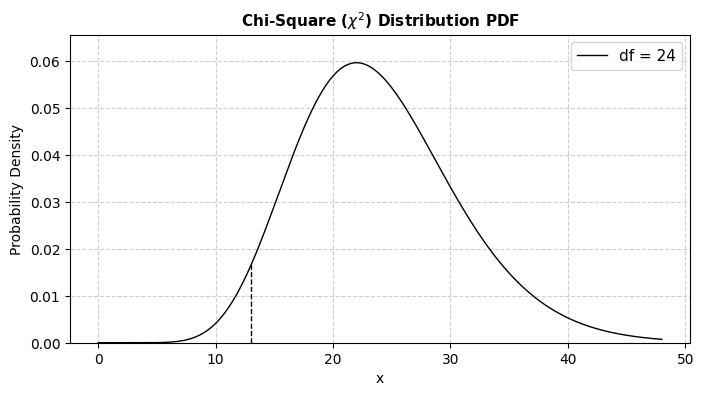

P(X <= 13) = 0.03387955906230818
0.95 확률 구간: 12.401150217444435 39.36407702660391


In [9]:
# 1. X축 범위 설정 (카이제곱 분포는 0 이상의 값만 가짐)
dof = 24
x = np.linspace(0, dof*2, 1000)   # x축, 자유도의 2배까지 설정.
y = chi2.pdf(x, df=dof)           # x에 대응되는 밀도

x_ref = 13                                # 분포에서 살펴볼 경계점, 편한대로 설정.
x_look = [x_ref, x_ref ]                  # 히스토그램에 표시할 x 좌표
y_look = [0, chi2.pdf(x_look[1], df=dof)] # 히스토그램에 표시할 y 좌표
y_max = max(y)*1.1                # Y축 레이블 범위를 보기 좋게 제한할 값.

plt.figure(figsize=(8, 4))
plt.plot(x, y, label=f'df = {dof}', color='black', linewidth=1)
plt.plot(x_look, y_look, linestyle='--', lw=1, color='black' )   # 경계 지점, 점선.

plt.title('Chi-Square ($ \\chi^2$) Distribution PDF', fontsize=11, fontweight='bold')
plt.xlabel('x', fontsize=10)
plt.ylabel('Probability Density', fontsize=10)
plt.ylim(0, y_max)                 # Y축 레이블 범위를 보기 좋게 제한
plt.grid(True, linestyle='--',  alpha=0.6)
plt.legend(fontsize=11)
plt.show()

x_below = x_look[1]
prob = chi2.cdf(x_below, df=dof)
print(f"P(X <= {x_below}) = {prob}" )

sig_lvl = 0.05
cnf_lvl = 1-sig_lvl
cv_lft = chi2.ppf( sig_lvl / 2 , df=dof)
cv_rgt = chi2.ppf( 1- sig_lvl / 2, df=dof)
print(f"{cnf_lvl} 확률 구간:", cv_lft, cv_rgt)
